# Exploratory Data Analysis (EDA)

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns

# Affichage propre
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
# Load the dataset using KaggleHub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

In [3]:
# Load the dataset into a DataFrame
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Shape:\n", df.shape)
print("Infos:\n", df.info())
print("Statistical infos:\n", df.describe())

Shape:
 (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

### EDA - Initial Observations : 

- **Size**: 284,807 rows, 31 columns.

- **Infos**: no missing values, all columns are float64 except Class (int64) -> no cleaning to do.

- **Statistical infos**: 
    - **Time**: from 0 to 172,792 seconds, or approximately 48 hours of recorded transactions. The average of 94,813 seconds indicates a fairly even distribution over time.
    - **Amount**: 
        - Average: $88, but median only $88 -> highly skewed distribution, skewed upward by a few large transactions.
        - Max: $25,691: probably exceptional purchases.
        - This skew justifies normalizing Amount during preprocessing with StandardScaler.

    - **V1-V28**: means very close to 0 and standard deviations around 1 -> normal because these are PCA components already centered and scaled by definition. No need to normalize them.
    - **Class**: mean of 0.001727, or exactly 0.17% fraud. The skewness is confirmed by statistics: the Q1, median and Q3 quartiles are all 0 -> accuracy is not a valid metric.

In [6]:
# Class distribution
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(3))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827
1     0.173
Name: proportion, dtype: float64


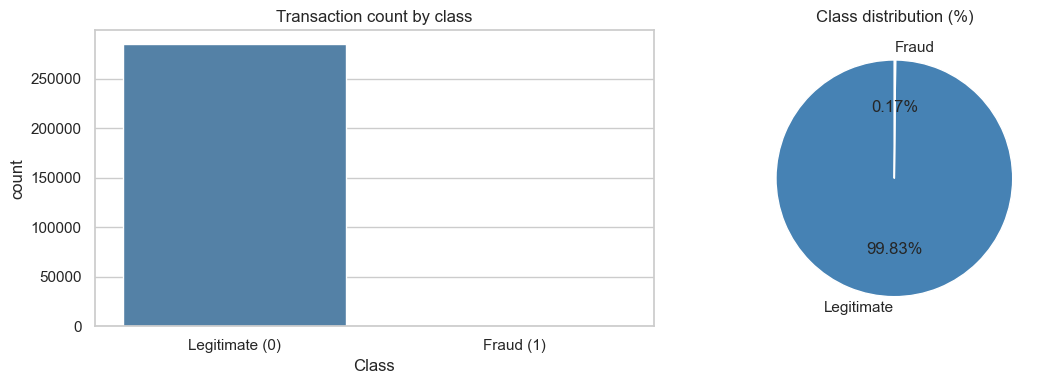

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: Transaction count by class
sns.countplot(x='Class', data=df, ax=axes[0], hue='Class', palette={0: 'steelblue', 1: 'crimson'}, legend=False)
axes[0].set_title('Transaction count by class')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])

# Graph 2: proportions
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Class distribution (%)')

plt.tight_layout()
plt.show()

The dataset is extremely imbalanced: only **0.17% of transactions are fraudulent** (492 out of 284,807).

A model that classifies **everything as legitimate** would reach **99.83% accuracy** and catch zero fraud.

- Accuracy is not a valid metric here.  
- We will use **Recall**, **F1-score** and **AUC-ROC** as primary metrics.

/var/folders/3m/nzcvgf2d6bgcl8_239kxg94w0000gn/T/ipykernel_4530/874727599.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


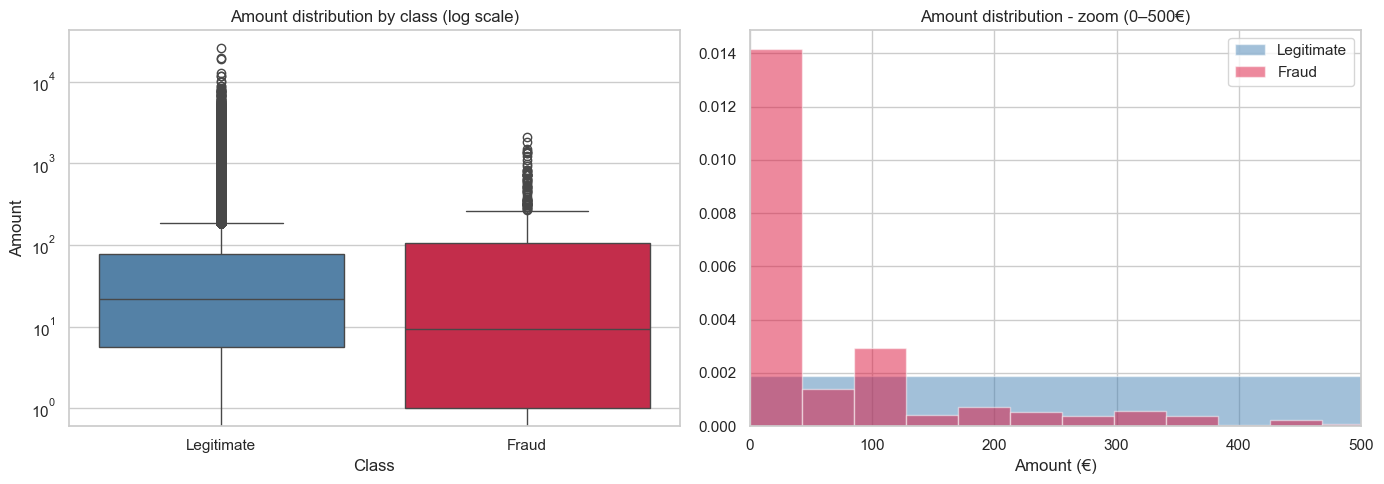

Legitimate - mean: 88.29€  |  median: 22.00€
Fraud      - mean: 122.21€  |  median: 9.25€


In [9]:
# Amount distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Complete distribution (log scale)
sns.boxplot(x='Class', y='Amount', data=df,
            hue='Class', palette={0: 'steelblue', 1: 'crimson'},
            legend=False, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Amount distribution by class (log scale)')
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Graph 2: zoom over small amounts
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[1].hist(legit, bins=50, alpha=0.5, color='steelblue', label='Legitimate', density=True)
axes[1].hist(fraud, bins=50, alpha=0.5, color='crimson', label='Fraud', density=True)
axes[1].set_xlim(0, 500)
axes[1].set_title('Amount distribution - zoom (0–500€)')
axes[1].set_xlabel('Amount (€)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Legitimate - mean: {legit.mean():.2f}€  |  median: {legit.median():.2f}€")
print(f"Fraud      - mean: {fraud.mean():.2f}€  |  median: {fraud.median():.2f}€")

**Box plot (left)**:
- The median for legitimate transactions (~€22) is higher than that for fraudulent ones (~€10).
- Legitimate transactions have outliers as high as €25,000: fraudulent ones top out at around €2,500.
- Fraudsters stay under the radar by avoiding large amounts.

**Histogram (right)**:
- The peak in fraud is heavily concentrated between €0 and €50.
- Legitimate transactions are distributed much more evenly between €0 and €500.
- This is a classic pattern: fraudsters start by testing with small amounts.

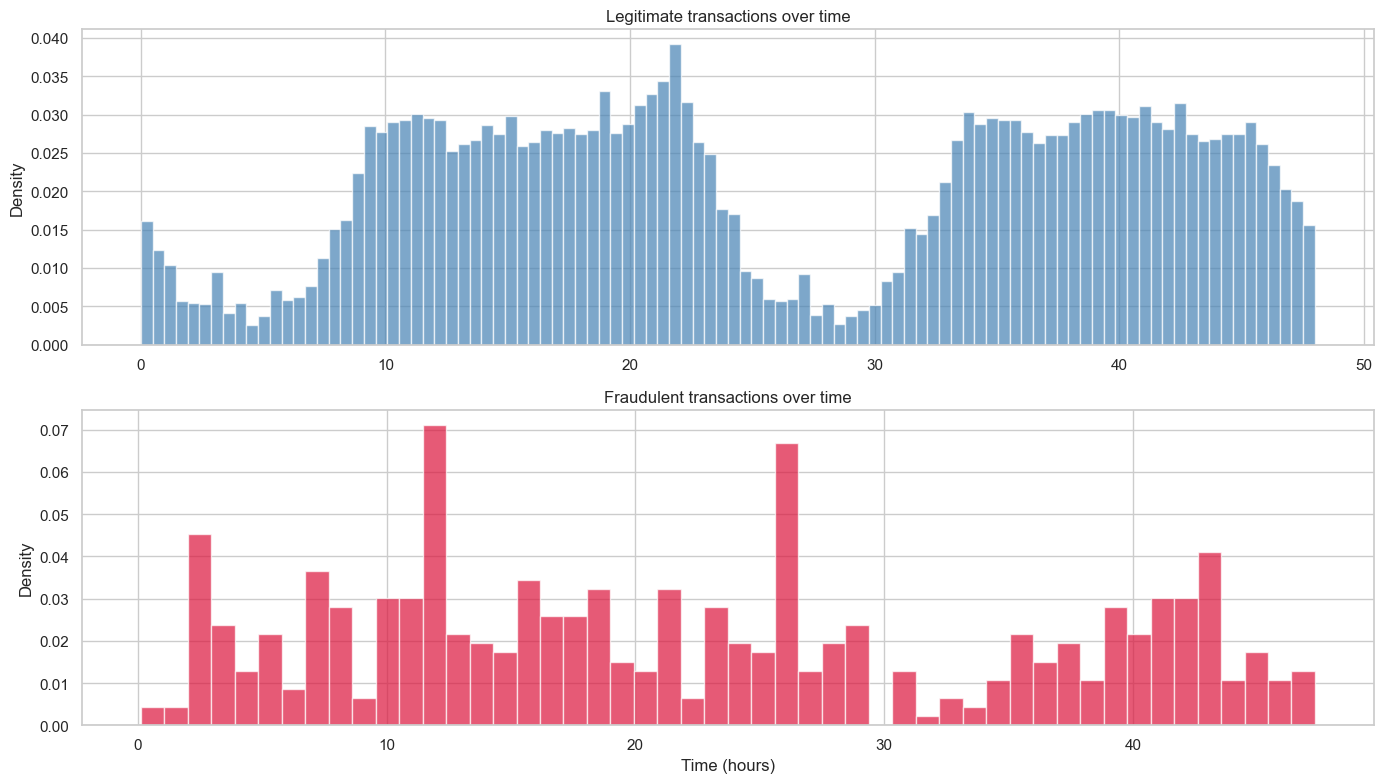

In [10]:
# Time distribution by class
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Hourly conversion
df['Time_hours'] = df['Time'] / 3600

# Graph 1: legitimate transactions
axes[0].hist(df[df['Class'] == 0]['Time_hours'], bins=100,
             color='steelblue', alpha=0.7, density=True)
axes[0].set_title('Legitimate transactions over time')
axes[0].set_ylabel('Density')

# Graph 2: fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Time_hours'], bins=50,
             color='crimson', alpha=0.7, density=True)
axes[1].set_title('Fraudulent transactions over time')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

- Legitimate transactions show two dips corresponding to nighttime hours (~8–16 and ~32-40).
- Fraudulent transactions are more evenly distributed, with a slight increase at night—when victims are not monitoring their accounts.

Time will be normalized with StandardScaler before modelling.

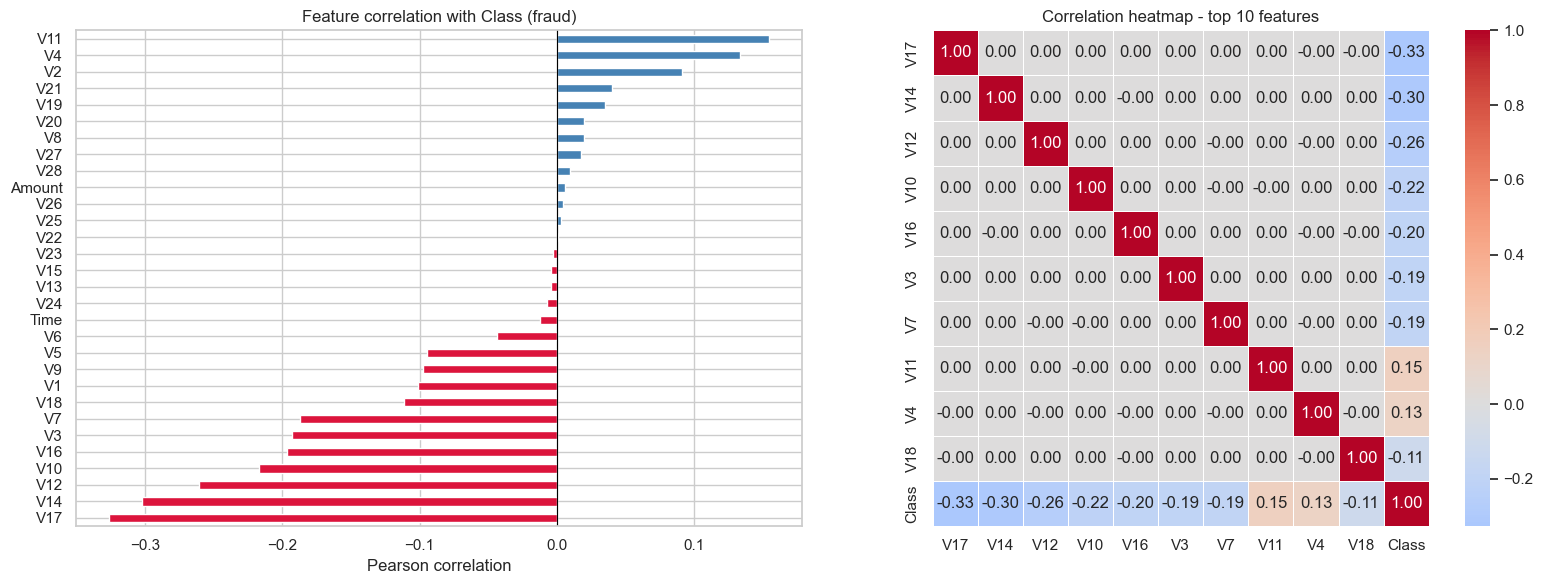

Top 5 positive correlations with fraud:
V19    0.035
V21    0.040
V2     0.091
V4     0.133
V11    0.155
Name: Class, dtype: float64

Top 5 negative correlations with fraud:
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
Name: Class, dtype: float64


In [11]:
# Correlation roadmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlations between all features and Class
correlations = df.drop(columns='Time_hours').corr()['Class'].drop('Class').sort_values()

# Graph 1: Bar chart of correlations using Class
colors = ['crimson' if c < 0 else 'steelblue' for c in correlations]
correlations.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Feature correlation with Class (fraud)')
axes[0].set_xlabel('Pearson correlation')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Graph 2: Heatmap of the most highly correlated top features
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('Class')
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title('Correlation heatmap - top 10 features')

plt.tight_layout()
plt.show()

# Top 5 Positive and Negative Correlations
print("Top 5 positive correlations with fraud:")
print(correlations.tail(5).round(3))
print("\nTop 5 negative correlations with fraud:")
print(correlations.head(5).round(3))

- **V17, V14, V12, V10, V16** show the strongest negative correlation with fraud: they are the most discriminating features.
- **V11, V4** show moderate positive correlation with fraud.
- All V1–V28 features are independent from each other (~0 inter-correlation), expected from PCA components, no multicollinearity risk.
- `Amount` and `Time` show very weak correlation with fraud alone, but remain useful in combination with other features.

Tree-based models (Random Forest, XGBoost) will likely leverage V17, V14, V12 heavily, we'll verify with feature importance plots.